# Recognizing HandWritten Digits in Scikit Learn
#### Objective
Use sklearn to train an MLP model on the handwritten digits dataset.

In [1]:
# importing hand written digit dataset
from sklearn import datasets

# digit contain the dataset
digits = datasets.load_digits()

# dir function, use to display the attributes of the datset
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

#### Understanding the attributes of the dataset
* `digits.image`: 3D array. Where the first dimension indexes images, and we can see that there are 1797 in total.
* The second and third dimension relate to image's pixels' x and y coordinates.
* Each image is 8x8 = 64 pixels in size. In other terms, this array may be represented in 3D as a stack of 8x8 pixel images.

In [2]:
print(f"First dimension size: {len(digits.images)}")

# outputting the picture value
print(digits.images[0])

First dimension size: 1797
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


We can now see that the resolution of the original digits was reduced to allow training a ML system to recognize these digits easier and faster.
Because at such a low resolution, even a human would struggle to recognize some of the digits. The low quality of the input photos will also limit our neural network in these settings.

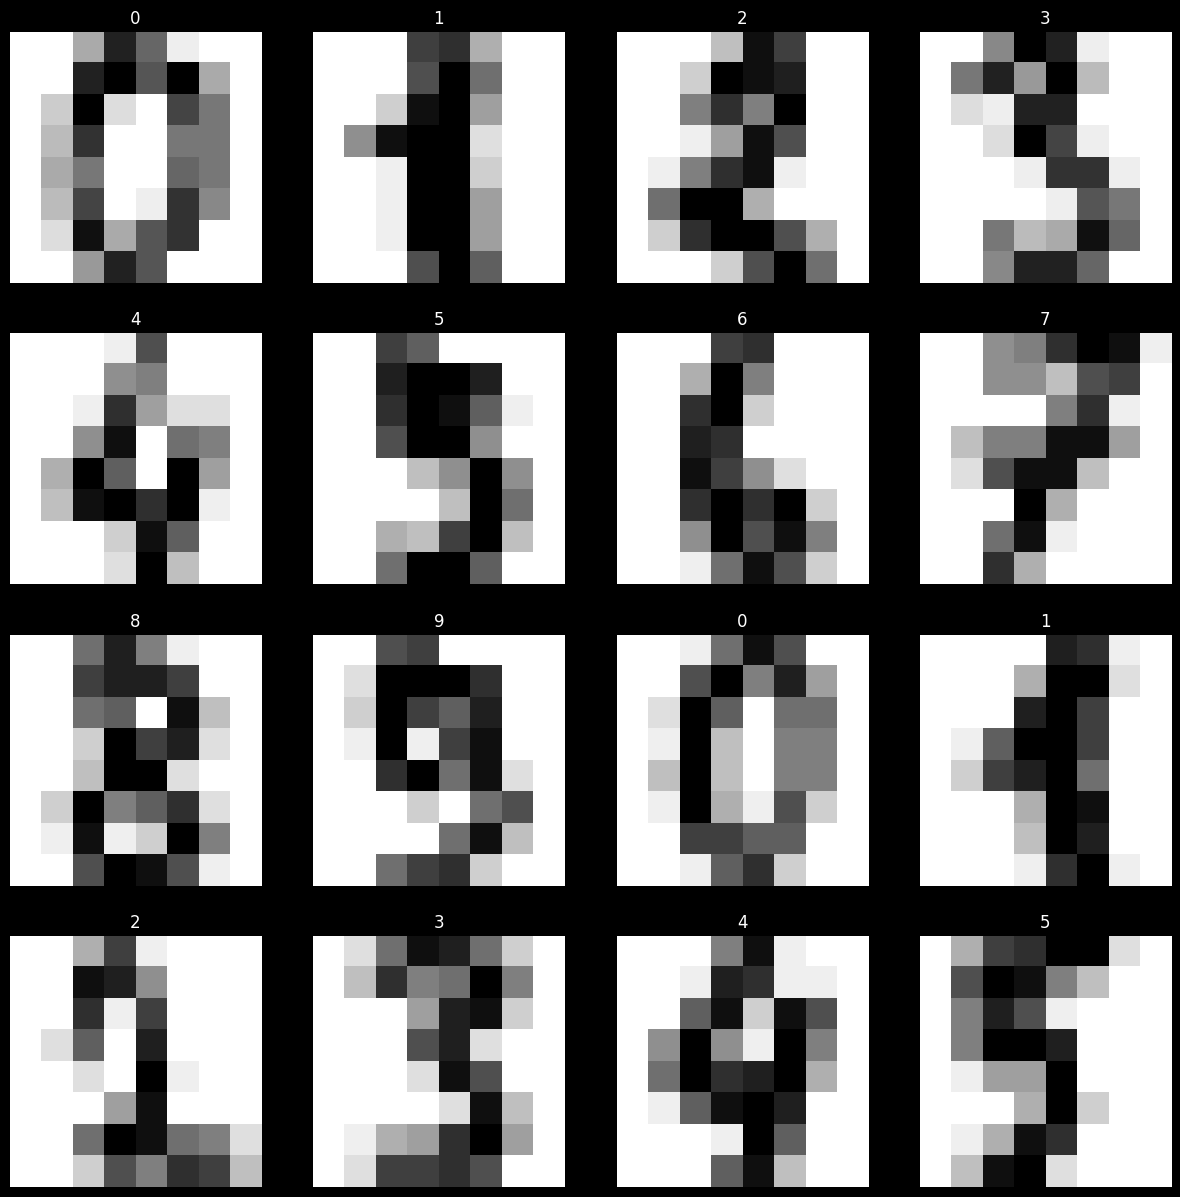

In [3]:
# importing the matplotlib libraries
import matplotlib.pyplot as plt

# defining function to plot digits
def plot_multi(i):
    nplots = 16
    fig = plt.figure(figsize=(15, 15))
    for j in range(nplots):
        plt.subplot(4, 4, j+1)
        plt.imshow(digits.images[i+j], cmap='binary')
        plt.title(digits.target[i+j])
        plt.axis('off')

# printing each digit in the dataset
plt.show()
plot_multi(0)

In [ ]:
%%sql


### Training Neural network with the dataset
In this context the neural network is this made:
* an input layer consisting of 64 nodes, one for each pixel in the input pictures. They simply send their input value to the neurons of the following layer.
* This is a dens neural network, meaning each node in each layer is linked to all nodes in the preceding and following levels.

We need to flat the images because the input layer expects a one-dimensional array, whereas the image datasets are two-dimensional.

In [4]:
# converting 2D array to 1D
y = digits.target
x = digits.images.reshape((len(digits.images), -1))

# chek the shape
x.shape

(1797, 64)

In [5]:
# printing the 1D array to check if is worked
x[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

### Data split for training and testing

In [6]:
# importing train test split
from sklearn.model_selection import train_test_split
# using the train test split function
X_train, X_test, y_train, y_test = train_test_split(x,y ,
                                   random_state=104,
                                   test_size=0.25,
                                   shuffle=True)

### Using a Multi-Layer Perceptron classifier
We connect neurons, inorder to build the neural network, so that their outputs become the inputs of the other neurons.

At first, we considered using RELU, but the `digits` dataset in scikit-learn contains pixels with values ranging from 0 to 16.
* **With the logistic function**: the function forcibly “squeezes” these values between 0 and 1. Even if the initial weights are large, the sigmoid acts as a “handbrake,” keeping the signals under control.
* **With ReLU**: There is no upper bound ($f(x)=x$ for $x>0$). If you multiply an input of 16 by an initial weight and a learning_rate_init=0.1 (which is very high for ReLU), the neuron values explode toward infinity in just a few iterations. The weights become so large that the model “goes haywire” numerically and accuracy plummets.

So we decide to use the logistic.

In [7]:
# importing the MLP classifier from sklearn
from sklearn.neural_network import MLPClassifier

# calling the MPL classifier with specific parameters
mlp = MLPClassifier(hidden_layer_sizes=(15,), # 1 layer with 15 perceptrons
                    activation='logistic',
                    alpha=1e-4, solver='sgd', # we use stochastic for optimization reasons and alpha for L2 reg
                    tol=1e-4, random_state=1, # for reproducibility
                    learning_rate_init=.1, # quite high but should work
                    verbose=True)

In [8]:
# is time to train the MLP model on the training set
mlp.fit(X_train, y_train)

Iteration 1, loss = 2.16529683
Iteration 2, loss = 1.76298030
Iteration 3, loss = 1.37275092
Iteration 4, loss = 1.02124589
Iteration 5, loss = 0.75362660
Iteration 6, loss = 0.57447277
Iteration 7, loss = 0.44887495
Iteration 8, loss = 0.36923565
Iteration 9, loss = 0.31272764
Iteration 10, loss = 0.27106692
Iteration 11, loss = 0.23878615
Iteration 12, loss = 0.21414152
Iteration 13, loss = 0.19356101
Iteration 14, loss = 0.18412665
Iteration 15, loss = 0.16530162
Iteration 16, loss = 0.15350098
Iteration 17, loss = 0.14032499
Iteration 18, loss = 0.12984313
Iteration 19, loss = 0.11982161
Iteration 20, loss = 0.11421545
Iteration 21, loss = 0.10895433
Iteration 22, loss = 0.10435745
Iteration 23, loss = 0.10093275
Iteration 24, loss = 0.09244378
Iteration 25, loss = 0.08819025
Iteration 26, loss = 0.08503616
Iteration 27, loss = 0.08113161
Iteration 28, loss = 0.07736869
Iteration 29, loss = 0.07283341
Iteration 30, loss = 0.06808659
Iteration 31, loss = 0.06657068
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(15,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.1
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


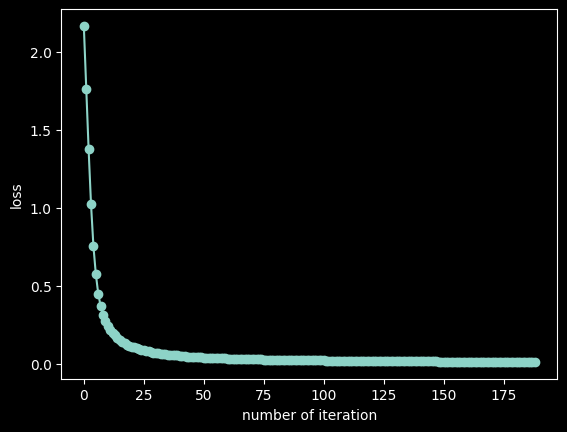

In [9]:
# plotting the loss for graphical visualization
fig, axes = plt.subplots(1, 1)
axes.plot(mlp.loss_curve_, 'o-')
axes.set_xlabel("number of iteration")
axes.set_ylabel("loss")
plt.show()

### Model Evaluation
Now let's check the model's performance using the test set, we do that to check if the model has learnt the pattern in the digit or it just has memorized it.

In [10]:
predictions = mlp.predict(X_test)
predictions[:50]

array([0, 1, 6, 1, 5, 7, 2, 4, 7, 4, 7, 3, 8, 2, 1, 1, 6, 5, 9, 1, 4, 8,
       5, 5, 5, 0, 2, 3, 4, 7, 1, 8, 1, 5, 0, 9, 4, 7, 3, 2, 6, 9, 5, 7,
       1, 6, 9, 6, 4, 2])

But the true labels or we can say that the ground truth labels were as shown below.

In [11]:
y_test[:50]

array([0, 1, 6, 1, 5, 7, 2, 4, 7, 4, 7, 3, 8, 2, 1, 1, 6, 5, 9, 1, 4, 8,
       5, 5, 5, 0, 2, 3, 4, 7, 4, 8, 1, 5, 0, 9, 4, 7, 3, 2, 6, 9, 5, 7,
       1, 6, 9, 6, 4, 2])

In [12]:
# importing the accuracy_score from the sklearn
from sklearn.metrics import accuracy_score

# calculating the accuracy with y_test and predictions
accuracy_score(y_test, predictions)

0.9711111111111111

### Investigating the results
The first improving could be a k-fold cross validation, this because we have a small dataset.

In [13]:
from sklearn.model_selection import cross_val_score

# let's execute the cross-validation on the entire dataset
# we divide the data in 5 folds
scores = cross_val_score(mlp, x, y, cv=5)

print("Accuracy for every fold: ", scores)
print("Average accuracy: ", scores.mean())
print("Standard deviation: ", scores.std())

Iteration 1, loss = 2.14963657
Iteration 2, loss = 1.70754578
Iteration 3, loss = 1.26538856
Iteration 4, loss = 0.91603134
Iteration 5, loss = 0.67210317
Iteration 6, loss = 0.51299869
Iteration 7, loss = 0.43849542
Iteration 8, loss = 0.34928709
Iteration 9, loss = 0.28737756
Iteration 10, loss = 0.24695650
Iteration 11, loss = 0.21741101
Iteration 12, loss = 0.19095524
Iteration 13, loss = 0.16857917
Iteration 14, loss = 0.15648680
Iteration 15, loss = 0.15205741
Iteration 16, loss = 0.13736996
Iteration 17, loss = 0.11949564
Iteration 18, loss = 0.11080871
Iteration 19, loss = 0.10627884
Iteration 20, loss = 0.09685392
Iteration 21, loss = 0.10067290
Iteration 22, loss = 0.09191085
Iteration 23, loss = 0.08203410
Iteration 24, loss = 0.07890846
Iteration 25, loss = 0.07560002
Iteration 26, loss = 0.07097850
Iteration 27, loss = 0.06933843
Iteration 28, loss = 0.09784222
Iteration 29, loss = 0.07144799
Iteration 30, loss = 0.06487129
Iteration 31, loss = 0.05990190
Iteration 32, los

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 123, loss = 0.01745649
Iteration 124, loss = 0.01739034
Iteration 125, loss = 0.01732511
Iteration 126, loss = 0.01731448
Iteration 127, loss = 0.01725814
Iteration 128, loss = 0.01697347
Iteration 129, loss = 0.01717140
Iteration 130, loss = 0.01684944
Iteration 131, loss = 0.01680337
Iteration 132, loss = 0.01651335
Iteration 133, loss = 0.01652829
Iteration 134, loss = 0.01654319
Iteration 135, loss = 0.01655457
Iteration 136, loss = 0.01630795
Iteration 137, loss = 0.01612826
Iteration 138, loss = 0.01595726
Iteration 139, loss = 0.01594155
Iteration 140, loss = 0.01592590
Iteration 141, loss = 0.01595804
Iteration 142, loss = 0.01589836
Iteration 143, loss = 0.01590541
Iteration 144, loss = 0.01560370
Iteration 145, loss = 0.01569129
Iteration 146, loss = 0.01564436
Iteration 147, loss = 0.01557006
Iteration 148, loss = 0.01527861
Iteration 149, loss = 0.01532186
Iteration 150, loss = 0.01518654
Iteration 151, loss = 0.01504974
Iteration 152, loss = 0.01488973
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 69, loss = 0.02455454
Iteration 70, loss = 0.02430993
Iteration 71, loss = 0.02524748
Iteration 72, loss = 0.02362797
Iteration 73, loss = 0.02410625
Iteration 74, loss = 0.02254748
Iteration 75, loss = 0.02268887
Iteration 76, loss = 0.02188242
Iteration 77, loss = 0.02199546
Iteration 78, loss = 0.02189724
Iteration 79, loss = 0.02123951
Iteration 80, loss = 0.02095830
Iteration 81, loss = 0.02110709
Iteration 82, loss = 0.02024608
Iteration 83, loss = 0.01998235
Iteration 84, loss = 0.01963073
Iteration 85, loss = 0.01942681
Iteration 86, loss = 0.01985483
Iteration 87, loss = 0.01912615
Iteration 88, loss = 0.01900022
Iteration 89, loss = 0.01865391
Iteration 90, loss = 0.01845675
Iteration 91, loss = 0.01842237
Iteration 92, loss = 0.01833559
Iteration 93, loss = 0.01808282
Iteration 94, loss = 0.01814482
Iteration 95, loss = 0.01795172
Iteration 96, loss = 0.01760857
Iteration 97, loss = 0.01746487
Iteration 98, loss = 0.01724304
Iteration 99, loss = 0.01683851
Iteratio

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 134, loss = 0.01251614
Iteration 135, loss = 0.01237298
Iteration 136, loss = 0.01242075
Iteration 137, loss = 0.01215650
Iteration 138, loss = 0.01203049
Iteration 139, loss = 0.01204219
Iteration 140, loss = 0.01201324
Iteration 141, loss = 0.01186717
Iteration 142, loss = 0.01178403
Iteration 143, loss = 0.01166863
Iteration 144, loss = 0.01170721
Iteration 145, loss = 0.01153657
Iteration 146, loss = 0.01144169
Iteration 147, loss = 0.01134337
Iteration 148, loss = 0.01131604
Iteration 149, loss = 0.01123779
Iteration 150, loss = 0.01116757
Iteration 151, loss = 0.01110299
Iteration 152, loss = 0.01108515
Iteration 153, loss = 0.01096334
Iteration 154, loss = 0.01089080
Iteration 155, loss = 0.01077430
Iteration 156, loss = 0.01081843
Iteration 157, loss = 0.01068507
Iteration 158, loss = 0.01068118
Iteration 159, loss = 0.01070608
Iteration 160, loss = 0.01059371
Iteration 161, loss = 0.01045288
Iteration 162, loss = 0.01038099
Iteration 163, loss = 0.01081423
Iteration 


These numbers show us exactly why cross-validation is an essential tool in machine learning.

If we look closely at the data we obtained:

In the first train_test_split, we achieved an accuracy of 97.1%.

Now, the average accuracy calculated across five different splits of the dataset has dropped to 92.1%.

We also notice a significant fluctuation across the different folds: in one case, the model drops to 88.8%, while in another, it rises to 96.1%.

Given this discrepancy between the initial evaluation and the actual average, we can infer that the initial 97.1% accuracy was partly due to “luck” in how the data was shuffled and split at the beginning.

Now that we know the model is wrong about 8% of the time, the next logical step is to figure out which numbers it confuses. Does it often mix up 3 and 8? Or 1 and 7?

To see this visually, the ideal tool is the confusion matrix

Iteration 1, loss = 2.14963657
Iteration 2, loss = 1.70754578
Iteration 3, loss = 1.26538856
Iteration 4, loss = 0.91603134
Iteration 5, loss = 0.67210317
Iteration 6, loss = 0.51299869
Iteration 7, loss = 0.43849542
Iteration 8, loss = 0.34928709
Iteration 9, loss = 0.28737756
Iteration 10, loss = 0.24695650
Iteration 11, loss = 0.21741101
Iteration 12, loss = 0.19095524
Iteration 13, loss = 0.16857917
Iteration 14, loss = 0.15648680
Iteration 15, loss = 0.15205741
Iteration 16, loss = 0.13736996
Iteration 17, loss = 0.11949564
Iteration 18, loss = 0.11080871
Iteration 19, loss = 0.10627884
Iteration 20, loss = 0.09685392
Iteration 21, loss = 0.10067290
Iteration 22, loss = 0.09191085
Iteration 23, loss = 0.08203410
Iteration 24, loss = 0.07890846
Iteration 25, loss = 0.07560002
Iteration 26, loss = 0.07097850
Iteration 27, loss = 0.06933843
Iteration 28, loss = 0.09784222
Iteration 29, loss = 0.07144799
Iteration 30, loss = 0.06487129
Iteration 31, loss = 0.05990190
Iteration 32, los

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 162, loss = 0.01473071
Iteration 163, loss = 0.01452428
Iteration 164, loss = 0.01428258
Iteration 165, loss = 0.01465321
Iteration 166, loss = 0.01450816
Iteration 167, loss = 0.01424959
Iteration 168, loss = 0.01421952
Iteration 169, loss = 0.01412094
Iteration 170, loss = 0.01401234
Iteration 171, loss = 0.01383300
Iteration 172, loss = 0.01378852
Iteration 173, loss = 0.01469412
Iteration 174, loss = 0.01366397
Iteration 175, loss = 0.01362468
Iteration 176, loss = 0.01354730
Iteration 177, loss = 0.01342179
Iteration 178, loss = 0.01340644
Iteration 179, loss = 0.01337222
Iteration 180, loss = 0.01334678
Iteration 181, loss = 0.01315226
Iteration 182, loss = 0.01316852
Iteration 183, loss = 0.01305051
Iteration 184, loss = 0.01299365
Iteration 185, loss = 0.01292864
Iteration 186, loss = 0.01297980
Iteration 187, loss = 0.01283692
Iteration 188, loss = 0.01280626
Iteration 189, loss = 0.01288551
Iteration 190, loss = 0.01268906
Iteration 191, loss = 0.01262782
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 141, loss = 0.01230198
Iteration 142, loss = 0.01200396
Iteration 143, loss = 0.01200652
Iteration 144, loss = 0.01183345
Iteration 145, loss = 0.01181204
Iteration 146, loss = 0.01168527
Iteration 147, loss = 0.01162053
Iteration 148, loss = 0.01160241
Iteration 149, loss = 0.01158573
Iteration 150, loss = 0.01141690
Iteration 151, loss = 0.01134058
Iteration 152, loss = 0.01133416
Iteration 153, loss = 0.01122628
Iteration 154, loss = 0.01141823
Iteration 155, loss = 0.01119432
Iteration 156, loss = 0.01136224
Iteration 157, loss = 0.01110520
Iteration 158, loss = 0.01094444
Iteration 159, loss = 0.01121099
Iteration 160, loss = 0.01101608
Iteration 161, loss = 0.01072904
Iteration 162, loss = 0.01065583
Iteration 163, loss = 0.01066613
Iteration 164, loss = 0.01056712
Iteration 165, loss = 0.01044703
Iteration 166, loss = 0.01047024
Iteration 167, loss = 0.01035131
Iteration 168, loss = 0.01030832
Iteration 169, loss = 0.01021612
Iteration 170, loss = 0.01018218
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 89, loss = 0.01937481
Iteration 90, loss = 0.01901353
Iteration 91, loss = 0.01856154
Iteration 92, loss = 0.01859023
Iteration 93, loss = 0.01861614
Iteration 94, loss = 0.01803317
Iteration 95, loss = 0.01792633
Iteration 96, loss = 0.01765883
Iteration 97, loss = 0.01736110
Iteration 98, loss = 0.01695071
Iteration 99, loss = 0.01668709
Iteration 100, loss = 0.01645951
Iteration 101, loss = 0.01636924
Iteration 102, loss = 0.01642762
Iteration 103, loss = 0.01627358
Iteration 104, loss = 0.01591442
Iteration 105, loss = 0.01587683
Iteration 106, loss = 0.01588707
Iteration 107, loss = 0.01569747
Iteration 108, loss = 0.01588570
Iteration 109, loss = 0.01534125
Iteration 110, loss = 0.01507168
Iteration 111, loss = 0.01490716
Iteration 112, loss = 0.01475385
Iteration 113, loss = 0.01469024
Iteration 114, loss = 0.01452327
Iteration 115, loss = 0.01462111
Iteration 116, loss = 0.01430550
Iteration 117, loss = 0.01423202
Iteration 118, loss = 0.01413956
Iteration 119, loss =

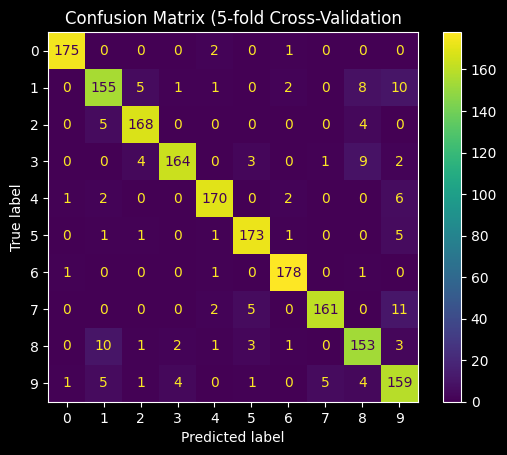

In [14]:
# importing the confusion matrix and cross validation prediction
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# 1. We generate predictions for the entire dataset (x) using cross-validation
cv_predictions = cross_val_predict(mlp, x, y, cv=5)

# 2. Let's create the cross-tabulation by cross-tabulating ALL the true labels (y) with the predictions (cv_predictions)
ConfusionMatrixDisplay.from_predictions(y, cv_predictions)
plt.title("Confusion Matrix (5-fold Cross-Validation")
plt.show()

When we cross-reference the row “True label = 8” with the column “Predicted label = 1,” we find as many as 10 errors. The reverse also occurs frequently: the true 1 is mistaken for an 8 in 8 cases.

Looking closely, there is also another interesting “hotspot”: the row True label = 7 crossed with the prediction 9 records 11 errors, the highest single value outside the diagonal. Furthermore, the number 1 is confused with 9 a full 10 times.

Now that we’ve identified these “critical pairs” (such as 8-1 or 7-9), the next step in understanding why the neural network gets confused is to take a closer look at these errors. At such a low resolution (8x8 pixels), a hastily written 8 could indeed resemble a 1.
Now let's use a filter to select those images so we can display them.

In [15]:
# making the boolean masks
errors_8_1 = (y == 8) & (cv_predictions == 1)
errors_7_9 = (y == 7) & (cv_predictions == 9)
errors_3_8 = (y == 3) & (cv_predictions == 8)

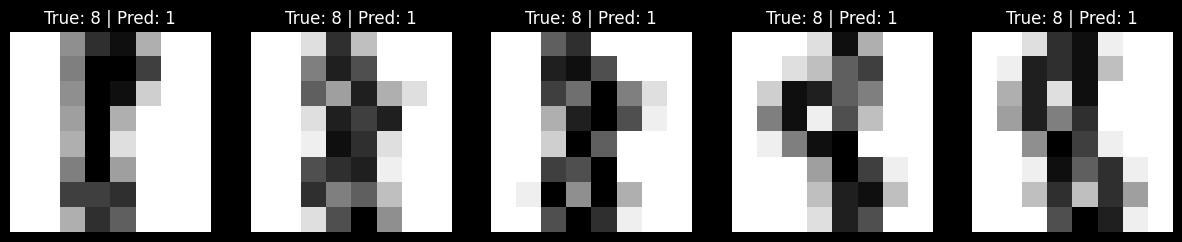

In [16]:
# filtering 8 and 1 images
errors_imag_8_1 = x[errors_8_1]

# printing the first 5 rows
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    if i < len(errors_imag_8_1):
        # reshape to original shape
        image_8x8 = errors_imag_8_1[i].reshape(8, 8)
        ax.imshow(image_8x8, cmap='binary')
        ax.set_title("True: 8 | Pred: 1")
    ax.axis('off')
plt.show()

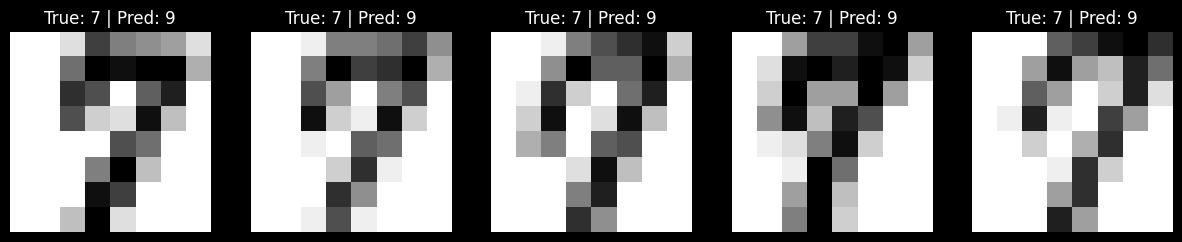

In [17]:
# filtering 7 and 9 images
errors_imag_7_9 = x[errors_7_9]

# printing the first 5 rows
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    if i < len(errors_imag_7_9):
        # reshape to original shape
        image_8x8 = errors_imag_7_9[i].reshape(8, 8)
        ax.imshow(image_8x8, cmap='binary')
        ax.set_title("True: 7 | Pred: 9")
    ax.axis('off')
plt.show()

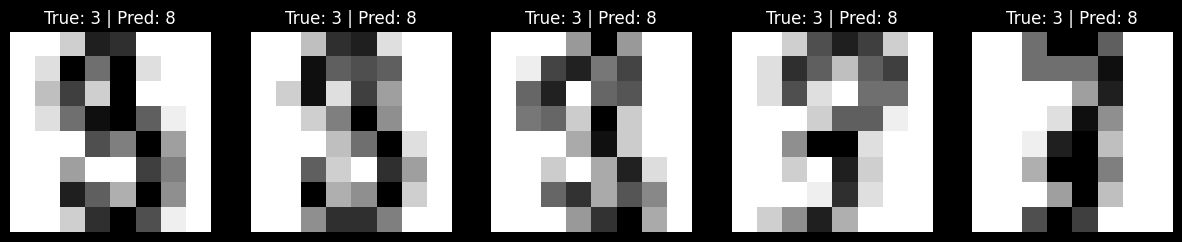

In [18]:
# filtering 1 and 9 images
errors_imag_3_8 = x[errors_3_8]

# printing the first 5 rows
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    if i < len(errors_imag_3_8):
        # reshape to original shape
        image_8x8 = errors_imag_3_8[i].reshape(8, 8)
        ax.imshow(image_8x8, cmap='binary')
        ax.set_title("True: 3 | Pred: 8")
    ax.axis('off')
plt.show()

We can see that in most cases it is difficult to actually distinguish the numbers; however, we must be careful when assessing this difficulty, since we know exactly what the numbers are when we look at them, and are therefore inclined to look for the specific pattern. It should be noted, however, that especially in the case of “8 predicted 1,” the digits are so confusing that they are almost impossible to recogn

## We can do better
Let's try with:
1. Data Pre-processing: scaling data (eg. 0, 1), neural networks should work better in that range
2. Hyperparameter tuning: we can use a grid search cross validation

Let's start with data scaling.

In [19]:
# importing the scaler
from sklearn.preprocessing import MinMaxScaler

# 1. initializing the scaler
scaler = MinMaxScaler()

# 2. Transforming the entire array of images
x_scaled = scaler.fit_transform(x)

# Re-compute the accuracy
scores_scaled = cross_val_score(mlp, x_scaled, y, cv=5)

print("Accuracy for every fold: ", scores_scaled)
print("Average accuracy: ", scores_scaled.mean())
print("Standard deviation: ", scores_scaled.std())

Iteration 1, loss = 2.32380072
Iteration 2, loss = 2.27213967
Iteration 3, loss = 2.22263886
Iteration 4, loss = 2.14844822
Iteration 5, loss = 2.04554301
Iteration 6, loss = 1.90180254
Iteration 7, loss = 1.72321558
Iteration 8, loss = 1.53273469
Iteration 9, loss = 1.34559471
Iteration 10, loss = 1.17772397
Iteration 11, loss = 1.03668477
Iteration 12, loss = 0.91604037
Iteration 13, loss = 0.81487905
Iteration 14, loss = 0.73288795
Iteration 15, loss = 0.66515663
Iteration 16, loss = 0.60518226
Iteration 17, loss = 0.55438592
Iteration 18, loss = 0.51318854
Iteration 19, loss = 0.47441236
Iteration 20, loss = 0.44273131
Iteration 21, loss = 0.41356585
Iteration 22, loss = 0.38865612
Iteration 23, loss = 0.36738457
Iteration 24, loss = 0.34750031
Iteration 25, loss = 0.32964173
Iteration 26, loss = 0.31353327
Iteration 27, loss = 0.29932212
Iteration 28, loss = 0.28576011
Iteration 29, loss = 0.27346732
Iteration 30, loss = 0.26339856
Iteration 31, loss = 0.25322087
Iteration 32, los

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 84, loss = 0.08641066
Iteration 85, loss = 0.08503150
Iteration 86, loss = 0.08344787
Iteration 87, loss = 0.08281668
Iteration 88, loss = 0.08199292
Iteration 89, loss = 0.08145100
Iteration 90, loss = 0.08072412
Iteration 91, loss = 0.07942831
Iteration 92, loss = 0.07911514
Iteration 93, loss = 0.07812404
Iteration 94, loss = 0.07673133
Iteration 95, loss = 0.07599144
Iteration 96, loss = 0.07566574
Iteration 97, loss = 0.07438164
Iteration 98, loss = 0.07360291
Iteration 99, loss = 0.07258591
Iteration 100, loss = 0.07189266
Iteration 101, loss = 0.07183915
Iteration 102, loss = 0.07106724
Iteration 103, loss = 0.07059499
Iteration 104, loss = 0.06970107
Iteration 105, loss = 0.06865550
Iteration 106, loss = 0.06823269
Iteration 107, loss = 0.06751785
Iteration 108, loss = 0.06670555
Iteration 109, loss = 0.06599623
Iteration 110, loss = 0.06557651
Iteration 111, loss = 0.06507243
Iteration 112, loss = 0.06433560
Iteration 113, loss = 0.06411013
Iteration 114, loss = 0.06

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 37, loss = 0.20071731
Iteration 38, loss = 0.19615362
Iteration 39, loss = 0.19053864
Iteration 40, loss = 0.18501490
Iteration 41, loss = 0.18187910
Iteration 42, loss = 0.17724388
Iteration 43, loss = 0.17301775
Iteration 44, loss = 0.16913518
Iteration 45, loss = 0.16609933
Iteration 46, loss = 0.16149369
Iteration 47, loss = 0.15909904
Iteration 48, loss = 0.15565476
Iteration 49, loss = 0.15321853
Iteration 50, loss = 0.14944589
Iteration 51, loss = 0.14676608
Iteration 52, loss = 0.14352070
Iteration 53, loss = 0.14112149
Iteration 54, loss = 0.13893368
Iteration 55, loss = 0.13714857
Iteration 56, loss = 0.13458044
Iteration 57, loss = 0.13237882
Iteration 58, loss = 0.13156387
Iteration 59, loss = 0.12837591
Iteration 60, loss = 0.12670522
Iteration 61, loss = 0.12476952
Iteration 62, loss = 0.12292517
Iteration 63, loss = 0.12128951
Iteration 64, loss = 0.11979952
Iteration 65, loss = 0.11806246
Iteration 66, loss = 0.11668819
Iteration 67, loss = 0.11460429
Iteratio

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 134, loss = 0.06112921
Iteration 135, loss = 0.06058380
Iteration 136, loss = 0.06015417
Iteration 137, loss = 0.05974202
Iteration 138, loss = 0.05932241
Iteration 139, loss = 0.05913259
Iteration 140, loss = 0.05838045
Iteration 141, loss = 0.05803487
Iteration 142, loss = 0.05751711
Iteration 143, loss = 0.05706562
Iteration 144, loss = 0.05657153
Iteration 145, loss = 0.05637540
Iteration 146, loss = 0.05575342
Iteration 147, loss = 0.05543327
Iteration 148, loss = 0.05524886
Iteration 149, loss = 0.05462915
Iteration 150, loss = 0.05418720
Iteration 151, loss = 0.05380746
Iteration 152, loss = 0.05361314
Iteration 153, loss = 0.05311326
Iteration 154, loss = 0.05299781
Iteration 155, loss = 0.05311303
Iteration 156, loss = 0.05199414
Iteration 157, loss = 0.05210525
Iteration 158, loss = 0.05162894
Iteration 159, loss = 0.05144101
Iteration 160, loss = 0.05048818
Iteration 161, loss = 0.05059783
Iteration 162, loss = 0.05019480
Iteration 163, loss = 0.05024961
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 79, loss = 0.07684195
Iteration 80, loss = 0.07616523
Iteration 81, loss = 0.07499440
Iteration 82, loss = 0.07382441
Iteration 83, loss = 0.07300976
Iteration 84, loss = 0.07244980
Iteration 85, loss = 0.07159825
Iteration 86, loss = 0.07093645
Iteration 87, loss = 0.06939752
Iteration 88, loss = 0.06866804
Iteration 89, loss = 0.06822159
Iteration 90, loss = 0.06741150
Iteration 91, loss = 0.06602219
Iteration 92, loss = 0.06567489
Iteration 93, loss = 0.06508505
Iteration 94, loss = 0.06416277
Iteration 95, loss = 0.06298706
Iteration 96, loss = 0.06256083
Iteration 97, loss = 0.06240555
Iteration 98, loss = 0.06117026
Iteration 99, loss = 0.06050170
Iteration 100, loss = 0.05994405
Iteration 101, loss = 0.05921312
Iteration 102, loss = 0.05853888
Iteration 103, loss = 0.05807554
Iteration 104, loss = 0.05747858
Iteration 105, loss = 0.05687239
Iteration 106, loss = 0.05670348
Iteration 107, loss = 0.05596729
Iteration 108, loss = 0.05514940
Iteration 109, loss = 0.0551813

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


The data speaks for itself: the average accuracy rose from 92.1% to 93.5% simply by scaling the pixels!

This demonstrates just how sensitive neural networks are to the range of input data. By working with values compressed between 0 and 1, the algorithm (in your case, the SGD solver) has a much easier time calculating gradients and finds the solution more stably.

Now that the data is properly prepared, let’s move on to the final phase of optimization: finding the perfect architecture for the neural network using GridSearchCV.

In [20]:
from sklearn.model_selection import GridSearchCV

# 1. Let’s define three architectures to test
param_grid = {
    'hidden_layer_sizes': [(15,), (64,), (30, 15)]
}

# 2. Preparing the search tool
grid_search = GridSearchCV(mlp, param_grid, cv=5)

# 3. Let's kick off the competition using our scaled data!
grid_search.fit(x_scaled, y)

print("Winning configuration: ", grid_search.best_params_)
print("Accuracy achieved: ", grid_search.best_score_)

Iteration 1, loss = 2.32380072
Iteration 2, loss = 2.27213967
Iteration 3, loss = 2.22263886
Iteration 4, loss = 2.14844822
Iteration 5, loss = 2.04554301
Iteration 6, loss = 1.90180254
Iteration 7, loss = 1.72321558
Iteration 8, loss = 1.53273469
Iteration 9, loss = 1.34559471
Iteration 10, loss = 1.17772397
Iteration 11, loss = 1.03668477
Iteration 12, loss = 0.91604037
Iteration 13, loss = 0.81487905
Iteration 14, loss = 0.73288795
Iteration 15, loss = 0.66515663
Iteration 16, loss = 0.60518226
Iteration 17, loss = 0.55438592
Iteration 18, loss = 0.51318854
Iteration 19, loss = 0.47441236
Iteration 20, loss = 0.44273131
Iteration 21, loss = 0.41356585
Iteration 22, loss = 0.38865612
Iteration 23, loss = 0.36738457
Iteration 24, loss = 0.34750031
Iteration 25, loss = 0.32964173
Iteration 26, loss = 0.31353327
Iteration 27, loss = 0.29932212
Iteration 28, loss = 0.28576011
Iteration 29, loss = 0.27346732
Iteration 30, loss = 0.26339856
Iteration 31, loss = 0.25322087
Iteration 32, los

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 108, loss = 0.06670555
Iteration 109, loss = 0.06599623
Iteration 110, loss = 0.06557651
Iteration 111, loss = 0.06507243
Iteration 112, loss = 0.06433560
Iteration 113, loss = 0.06411013
Iteration 114, loss = 0.06317941
Iteration 115, loss = 0.06275795
Iteration 116, loss = 0.06257138
Iteration 117, loss = 0.06178062
Iteration 118, loss = 0.06164674
Iteration 119, loss = 0.06049338
Iteration 120, loss = 0.06005051
Iteration 121, loss = 0.05944074
Iteration 122, loss = 0.05923519
Iteration 123, loss = 0.05896623
Iteration 124, loss = 0.05868127
Iteration 125, loss = 0.05774519
Iteration 126, loss = 0.05702737
Iteration 127, loss = 0.05696916
Iteration 128, loss = 0.05605377
Iteration 129, loss = 0.05669411
Iteration 130, loss = 0.05558596
Iteration 131, loss = 0.05516372
Iteration 132, loss = 0.05429113
Iteration 133, loss = 0.05426488
Iteration 134, loss = 0.05373075
Iteration 135, loss = 0.05295366
Iteration 136, loss = 0.05288870
Iteration 137, loss = 0.05219015
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 55, loss = 0.13714857
Iteration 56, loss = 0.13458044
Iteration 57, loss = 0.13237882
Iteration 58, loss = 0.13156387
Iteration 59, loss = 0.12837591
Iteration 60, loss = 0.12670522
Iteration 61, loss = 0.12476952
Iteration 62, loss = 0.12292517
Iteration 63, loss = 0.12128951
Iteration 64, loss = 0.11979952
Iteration 65, loss = 0.11806246
Iteration 66, loss = 0.11668819
Iteration 67, loss = 0.11460429
Iteration 68, loss = 0.11298668
Iteration 69, loss = 0.11160415
Iteration 70, loss = 0.11015143
Iteration 71, loss = 0.10926100
Iteration 72, loss = 0.10825098
Iteration 73, loss = 0.10639209
Iteration 74, loss = 0.10517450
Iteration 75, loss = 0.10443666
Iteration 76, loss = 0.10291508
Iteration 77, loss = 0.10152552
Iteration 78, loss = 0.10006775
Iteration 79, loss = 0.09916512
Iteration 80, loss = 0.09867777
Iteration 81, loss = 0.09730199
Iteration 82, loss = 0.09610085
Iteration 83, loss = 0.09481962
Iteration 84, loss = 0.09420098
Iteration 85, loss = 0.09277714
Iteratio

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 116, loss = 0.07123521
Iteration 117, loss = 0.07047650
Iteration 118, loss = 0.06985921
Iteration 119, loss = 0.06946010
Iteration 120, loss = 0.06902922
Iteration 121, loss = 0.06820716
Iteration 122, loss = 0.06781609
Iteration 123, loss = 0.06717611
Iteration 124, loss = 0.06642576
Iteration 125, loss = 0.06596799
Iteration 126, loss = 0.06520661
Iteration 127, loss = 0.06472050
Iteration 128, loss = 0.06434496
Iteration 129, loss = 0.06381539
Iteration 130, loss = 0.06315989
Iteration 131, loss = 0.06289528
Iteration 132, loss = 0.06232760
Iteration 133, loss = 0.06162742
Iteration 134, loss = 0.06112921
Iteration 135, loss = 0.06058380
Iteration 136, loss = 0.06015417
Iteration 137, loss = 0.05974202
Iteration 138, loss = 0.05932241
Iteration 139, loss = 0.05913259
Iteration 140, loss = 0.05838045
Iteration 141, loss = 0.05803487
Iteration 142, loss = 0.05751711
Iteration 143, loss = 0.05706562
Iteration 144, loss = 0.05657153
Iteration 145, loss = 0.05637540
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 104, loss = 0.05747858
Iteration 105, loss = 0.05687239
Iteration 106, loss = 0.05670348
Iteration 107, loss = 0.05596729
Iteration 108, loss = 0.05514940
Iteration 109, loss = 0.05518130
Iteration 110, loss = 0.05445361
Iteration 111, loss = 0.05342153
Iteration 112, loss = 0.05333994
Iteration 113, loss = 0.05253866
Iteration 114, loss = 0.05240535
Iteration 115, loss = 0.05135384
Iteration 116, loss = 0.05103358
Iteration 117, loss = 0.05039219
Iteration 118, loss = 0.05006250
Iteration 119, loss = 0.04961922
Iteration 120, loss = 0.04955500
Iteration 121, loss = 0.04912937
Iteration 122, loss = 0.04845162
Iteration 123, loss = 0.04797500
Iteration 124, loss = 0.04723349
Iteration 125, loss = 0.04724635
Iteration 126, loss = 0.04657191
Iteration 127, loss = 0.04599346
Iteration 128, loss = 0.04566040
Iteration 129, loss = 0.04542403
Iteration 130, loss = 0.04500456
Iteration 131, loss = 0.04476205
Iteration 132, loss = 0.04416469
Iteration 133, loss = 0.04390046
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 29, loss = 0.19032899
Iteration 30, loss = 0.18318729
Iteration 31, loss = 0.17722184
Iteration 32, loss = 0.17262207
Iteration 33, loss = 0.16729993
Iteration 34, loss = 0.16376407
Iteration 35, loss = 0.15828249
Iteration 36, loss = 0.15422156
Iteration 37, loss = 0.15049535
Iteration 38, loss = 0.14795375
Iteration 39, loss = 0.14383709
Iteration 40, loss = 0.14270985
Iteration 41, loss = 0.13746354
Iteration 42, loss = 0.13438569
Iteration 43, loss = 0.13213273
Iteration 44, loss = 0.12955298
Iteration 45, loss = 0.12650765
Iteration 46, loss = 0.12568464
Iteration 47, loss = 0.12201601
Iteration 48, loss = 0.11964180
Iteration 49, loss = 0.11739448
Iteration 50, loss = 0.11649430
Iteration 51, loss = 0.11358073
Iteration 52, loss = 0.11220539
Iteration 53, loss = 0.10984321
Iteration 54, loss = 0.10917947
Iteration 55, loss = 0.10630104
Iteration 56, loss = 0.10480962
Iteration 57, loss = 0.10307257
Iteration 58, loss = 0.10278701
Iteration 59, loss = 0.10010526
Iteratio

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 72, loss = 0.08191634
Iteration 73, loss = 0.08047312
Iteration 74, loss = 0.08057373
Iteration 75, loss = 0.07870341
Iteration 76, loss = 0.07927869
Iteration 77, loss = 0.07935858
Iteration 78, loss = 0.07741862
Iteration 79, loss = 0.07515247
Iteration 80, loss = 0.07462820
Iteration 81, loss = 0.07480753
Iteration 82, loss = 0.07279763
Iteration 83, loss = 0.07286909
Iteration 84, loss = 0.07221004
Iteration 85, loss = 0.07105473
Iteration 86, loss = 0.06997263
Iteration 87, loss = 0.06906941
Iteration 88, loss = 0.06882733
Iteration 89, loss = 0.06791580
Iteration 90, loss = 0.06744052
Iteration 91, loss = 0.06659920
Iteration 92, loss = 0.06613785
Iteration 93, loss = 0.06513800
Iteration 94, loss = 0.06730286
Iteration 95, loss = 0.06407569
Iteration 96, loss = 0.06343960
Iteration 97, loss = 0.06296077
Iteration 98, loss = 0.06255984
Iteration 99, loss = 0.06163399
Iteration 100, loss = 0.06229554
Iteration 101, loss = 0.06232953
Iteration 102, loss = 0.06117081
Itera

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 89, loss = 0.07376979
Iteration 90, loss = 0.07178826
Iteration 91, loss = 0.07075118
Iteration 92, loss = 0.07007976
Iteration 93, loss = 0.07005682
Iteration 94, loss = 0.06904906
Iteration 95, loss = 0.06775212
Iteration 96, loss = 0.06744325
Iteration 97, loss = 0.06708414
Iteration 98, loss = 0.06649717
Iteration 99, loss = 0.06534135
Iteration 100, loss = 0.06507012
Iteration 101, loss = 0.06459653
Iteration 102, loss = 0.06372246
Iteration 103, loss = 0.06415294
Iteration 104, loss = 0.06261006
Iteration 105, loss = 0.06259784
Iteration 106, loss = 0.06250483
Iteration 107, loss = 0.06175802
Iteration 108, loss = 0.06113604
Iteration 109, loss = 0.06077407
Iteration 110, loss = 0.05907818
Iteration 111, loss = 0.05873520
Iteration 112, loss = 0.05821380
Iteration 113, loss = 0.05795733
Iteration 114, loss = 0.05775438
Iteration 115, loss = 0.05705820
Iteration 116, loss = 0.05626311
Iteration 117, loss = 0.05596402
Iteration 118, loss = 0.05557606
Iteration 119, loss =

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 74, loss = 0.08606584
Iteration 75, loss = 0.08530489
Iteration 76, loss = 0.08534713
Iteration 77, loss = 0.08452274
Iteration 78, loss = 0.08278731
Iteration 79, loss = 0.08163931
Iteration 80, loss = 0.08058318
Iteration 81, loss = 0.08057423
Iteration 82, loss = 0.07910741
Iteration 83, loss = 0.07772892
Iteration 84, loss = 0.07649984
Iteration 85, loss = 0.07627706
Iteration 86, loss = 0.07612759
Iteration 87, loss = 0.07674470
Iteration 88, loss = 0.07320588
Iteration 89, loss = 0.07425728
Iteration 90, loss = 0.07214892
Iteration 91, loss = 0.07118374
Iteration 92, loss = 0.07072492
Iteration 93, loss = 0.07050243
Iteration 94, loss = 0.06895690
Iteration 95, loss = 0.06822799
Iteration 96, loss = 0.06753193
Iteration 97, loss = 0.06801229
Iteration 98, loss = 0.06702845
Iteration 99, loss = 0.06693127
Iteration 100, loss = 0.06536144
Iteration 101, loss = 0.06419638
Iteration 102, loss = 0.06364535
Iteration 103, loss = 0.06338298
Iteration 104, loss = 0.06267448
Ite

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 70, loss = 0.06633992
Iteration 71, loss = 0.06526411
Iteration 72, loss = 0.06424035
Iteration 73, loss = 0.06345721
Iteration 74, loss = 0.06250644
Iteration 75, loss = 0.06229381
Iteration 76, loss = 0.06206864
Iteration 77, loss = 0.06088022
Iteration 78, loss = 0.06030980
Iteration 79, loss = 0.05882662
Iteration 80, loss = 0.05826056
Iteration 81, loss = 0.05808808
Iteration 82, loss = 0.05866638
Iteration 83, loss = 0.05680334
Iteration 84, loss = 0.05558743
Iteration 85, loss = 0.05518272
Iteration 86, loss = 0.05542236
Iteration 87, loss = 0.05388989
Iteration 88, loss = 0.05333923
Iteration 89, loss = 0.05272044
Iteration 90, loss = 0.05188531
Iteration 91, loss = 0.05152430
Iteration 92, loss = 0.05057820
Iteration 93, loss = 0.05060553
Iteration 94, loss = 0.04958425
Iteration 95, loss = 0.04949271
Iteration 96, loss = 0.04874576
Iteration 97, loss = 0.04878163
Iteration 98, loss = 0.04864854
Iteration 99, loss = 0.04785514
Iteration 100, loss = 0.04746822
Iterati

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 66, loss = 0.25526261
Iteration 67, loss = 0.25154737
Iteration 68, loss = 0.24084860
Iteration 69, loss = 0.23412323
Iteration 70, loss = 0.22719957
Iteration 71, loss = 0.22158868
Iteration 72, loss = 0.21482103
Iteration 73, loss = 0.21349485
Iteration 74, loss = 0.20394557
Iteration 75, loss = 0.19970678
Iteration 76, loss = 0.19500178
Iteration 77, loss = 0.19010043
Iteration 78, loss = 0.18562456
Iteration 79, loss = 0.18079328
Iteration 80, loss = 0.17886105
Iteration 81, loss = 0.17520381
Iteration 82, loss = 0.16975670
Iteration 83, loss = 0.16599122
Iteration 84, loss = 0.16161601
Iteration 85, loss = 0.15824476
Iteration 86, loss = 0.15548023
Iteration 87, loss = 0.15323522
Iteration 88, loss = 0.14967169
Iteration 89, loss = 0.14514622
Iteration 90, loss = 0.14243329
Iteration 91, loss = 0.14021385
Iteration 92, loss = 0.13777844
Iteration 93, loss = 0.13853054
Iteration 94, loss = 0.13230949
Iteration 95, loss = 0.12981793
Iteration 96, loss = 0.12738958
Iteratio

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 70, loss = 0.21110481
Iteration 71, loss = 0.20558027
Iteration 72, loss = 0.20112098
Iteration 73, loss = 0.19585268
Iteration 74, loss = 0.19039284
Iteration 75, loss = 0.18538730
Iteration 76, loss = 0.18273655
Iteration 77, loss = 0.17815640
Iteration 78, loss = 0.17317136
Iteration 79, loss = 0.16858757
Iteration 80, loss = 0.16769803
Iteration 81, loss = 0.16355751
Iteration 82, loss = 0.15988418
Iteration 83, loss = 0.15541245
Iteration 84, loss = 0.15146934
Iteration 85, loss = 0.14732759
Iteration 86, loss = 0.14483502
Iteration 87, loss = 0.14409079
Iteration 88, loss = 0.13988263
Iteration 89, loss = 0.13574664
Iteration 90, loss = 0.13449817
Iteration 91, loss = 0.13209736
Iteration 92, loss = 0.12813999
Iteration 93, loss = 0.12841067
Iteration 94, loss = 0.12514183
Iteration 95, loss = 0.12205302
Iteration 96, loss = 0.11945309
Iteration 97, loss = 0.11763308
Iteration 98, loss = 0.11456435
Iteration 99, loss = 0.11266551
Iteration 100, loss = 0.11270634
Iterati

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 78, loss = 0.18817998
Iteration 79, loss = 0.18600679
Iteration 80, loss = 0.18120388
Iteration 81, loss = 0.17694557
Iteration 82, loss = 0.17296824
Iteration 83, loss = 0.16954834
Iteration 84, loss = 0.16337490
Iteration 85, loss = 0.15895486
Iteration 86, loss = 0.15693779
Iteration 87, loss = 0.15312250
Iteration 88, loss = 0.15041238
Iteration 89, loss = 0.14561975
Iteration 90, loss = 0.14296651
Iteration 91, loss = 0.13918540
Iteration 92, loss = 0.13671066
Iteration 93, loss = 0.13464616
Iteration 94, loss = 0.13113894
Iteration 95, loss = 0.12903911
Iteration 96, loss = 0.12740809
Iteration 97, loss = 0.12799673
Iteration 98, loss = 0.12160503
Iteration 99, loss = 0.12123453
Iteration 100, loss = 0.11887260
Iteration 101, loss = 0.11659278
Iteration 102, loss = 0.11284862
Iteration 103, loss = 0.11196259
Iteration 104, loss = 0.10966485
Iteration 105, loss = 0.10715398
Iteration 106, loss = 0.10750662
Iteration 107, loss = 0.10491361
Iteration 108, loss = 0.10260366

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 101, loss = 0.11909373
Iteration 102, loss = 0.11665089
Iteration 103, loss = 0.11580121
Iteration 104, loss = 0.11338155
Iteration 105, loss = 0.11111069
Iteration 106, loss = 0.11182649
Iteration 107, loss = 0.10955800
Iteration 108, loss = 0.10563046
Iteration 109, loss = 0.10412399
Iteration 110, loss = 0.10256993
Iteration 111, loss = 0.10057153
Iteration 112, loss = 0.09837874
Iteration 113, loss = 0.09685866
Iteration 114, loss = 0.09558327
Iteration 115, loss = 0.09436766
Iteration 116, loss = 0.09302627
Iteration 117, loss = 0.09127936
Iteration 118, loss = 0.09075936
Iteration 119, loss = 0.09047487
Iteration 120, loss = 0.08767293
Iteration 121, loss = 0.08673896
Iteration 122, loss = 0.08510086
Iteration 123, loss = 0.08372939
Iteration 124, loss = 0.08265118
Iteration 125, loss = 0.08165201
Iteration 126, loss = 0.08184337
Iteration 127, loss = 0.08005700
Iteration 128, loss = 0.07836521
Iteration 129, loss = 0.07682651
Iteration 130, loss = 0.07596871
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 85, loss = 0.12896238
Iteration 86, loss = 0.12600334
Iteration 87, loss = 0.12258981
Iteration 88, loss = 0.12175483
Iteration 89, loss = 0.11676836
Iteration 90, loss = 0.11476806
Iteration 91, loss = 0.11389725
Iteration 92, loss = 0.11049168
Iteration 93, loss = 0.10837005
Iteration 94, loss = 0.10535217
Iteration 95, loss = 0.10352682
Iteration 96, loss = 0.10107984
Iteration 97, loss = 0.10018600
Iteration 98, loss = 0.09747250
Iteration 99, loss = 0.09794780
Iteration 100, loss = 0.09542615
Iteration 101, loss = 0.09147692
Iteration 102, loss = 0.09120898
Iteration 103, loss = 0.08953417
Iteration 104, loss = 0.08734274
Iteration 105, loss = 0.08579053
Iteration 106, loss = 0.08362975
Iteration 107, loss = 0.08299616
Iteration 108, loss = 0.08118435
Iteration 109, loss = 0.08054381
Iteration 110, loss = 0.07882188
Iteration 111, loss = 0.07860254
Iteration 112, loss = 0.07533576
Iteration 113, loss = 0.07741569
Iteration 114, loss = 0.07339714
Iteration 115, loss = 0.0

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 137, loss = 0.05594297
Iteration 138, loss = 0.05564350
Iteration 139, loss = 0.05521832
Iteration 140, loss = 0.05495218
Iteration 141, loss = 0.05454895
Iteration 142, loss = 0.05427659
Iteration 143, loss = 0.05391028
Iteration 144, loss = 0.05333869
Iteration 145, loss = 0.05297703
Iteration 146, loss = 0.05250164
Iteration 147, loss = 0.05239882
Iteration 148, loss = 0.05194080
Iteration 149, loss = 0.05148137
Iteration 150, loss = 0.05123446
Iteration 151, loss = 0.05058468
Iteration 152, loss = 0.05072854
Iteration 153, loss = 0.04983949
Iteration 154, loss = 0.04968233
Iteration 155, loss = 0.04944254
Iteration 156, loss = 0.04900844
Iteration 157, loss = 0.04866185
Iteration 158, loss = 0.04857025
Iteration 159, loss = 0.04806112
Iteration 160, loss = 0.04788246
Iteration 161, loss = 0.04773457
Iteration 162, loss = 0.04724370
Iteration 163, loss = 0.04701341
Iteration 164, loss = 0.04655875
Iteration 165, loss = 0.04615898
Iteration 166, loss = 0.04617958
Iteration 

/home/gugutca/PycharmProjects/ML_Personal_projects/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Final thoughts
The data speaks for itself: the original configuration (15,) won the competition!

This result provides us with a very valuable practical lesson. In machine learning, we often tend to think that “bigger is better,” but that’s not always true. Adding neurons or layers, as in the case of (64,) or (30, 15), greatly increases the mathematical complexity of the model.

On a relatively simple and small dataset like this (1,797 low-resolution images), a network that is too complex risks “memorizing” the training data, losing the ability to generalize to new data (the well-known phenomenon of overfitting 📉). The 15-neuron network, on the other hand, has proven to strike the perfect balance: it is complex enough to understand the patterns, yet simple enough not to get lost in unnecessary details.

## Saving the model


In [21]:
import joblib

# 1. Extracting the winner model
winner_model = grid_search.best_estimator_

# 2. Saving the NN
joblib.dump(winner_model, 'mlp_model_handwriting.pkl')

# 3. Saving the scaler
joblib.dump(scaler, 'handwriting_scaler.pkl')

print("Model and Scaler saved successfully")

Model and Scaler saved successfully


`# Ricarichiamo gli oggetti salvati `
`modello_caricato = joblib.load('mlp_model_handwriting.pkl')`
`scaler_caricato = joblib.load('handwriting_scaler.pkl')`

`# Scaliamo la nuova immagine e facciamo la previsione!`
`# nuova_immagine_scalata = scaler_caricato.transform(nuova_immagine)`
`# previsione = modello_caricato.predict(nuova_immagine_scalata)`